# 5.2 Reproducibility via Code Notebooks _and_
# 5.4 Best Practices for Reproducible Coding 

5.2 Create a notebook that does some simple EDA on some data. It should generate at **least one plot and at least one table**. Create a script to download the CDC dataset. Upload your work

5.4 Add documentation to your simple EDA notebook. Create a Makefile similar to the one shown in class (e.g., with commands to download the data, run the analysis, etc.). Upload your analysis file.

## Setup

This setup uses code from Dr. Rampure to import libraries and define functions for working with the CDC data. 

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

from IPython.display import display
from sklearn.compose import ColumnTransformer, make_column_transformer, make_column_selector
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, GridSearchCV, cross_validate, train_test_split
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, PolynomialFeatures, StandardScaler

ROOT = Path("/Users/higgins/Documents/UWGrad/Conferences_Apps_Projects/DAIR3/DAIR3-Workshop/resources/unit_4")
DATA_DIR = ROOT / "data"
IMAGE_DIR = ROOT / "images"
RANDOM_STATE = 42

pd.options.plotting.backend = "plotly"
pio.templates["palatino_white"] = go.layout.Template(pio.templates["plotly_white"])
pio.templates["palatino_white"].layout.font.family = "Palatino, Palatino Linotype, Book Antiqua, serif"
pio.templates["palatino_white"].data.scatter = [go.Scatter(marker={"size": 8})]
pio.templates["palatino_white"].data.scattergl = [go.Scattergl(marker={"size": 8})]
pio.templates.default = "palatino_white"
px.defaults.template = "palatino_white"
px.defaults.width = 840
px.defaults.height = 460


def display_df(df, rows=10):
    return display(df.head(rows))


def make_polynomial_sample(n=80, random_state=23):
    rng = np.random.default_rng(random_state)
    x = np.linspace(-5, 5, n)
    y = 2 + 0.8 * x - 0.35 * x ** 2 + 0.08 * x ** 3 + rng.normal(0, 3, n)
    return pd.DataFrame({"x": x, "y": y})


def one_hot_encoder(**kwargs):
    try:
        return OneHotEncoder(sparse_output=False, **kwargs)
    except TypeError:
        return OneHotEncoder(sparse=False, **kwargs)


def find_birthweight_file(year=1971):
    candidates = [
        DATA_DIR / f"{year}.csv.gz",
        ROOT.parent / "DAIR3-Workshop" / "resources" / "unit_3" / "data" / f"{year}.csv.gz",
        ROOT.parent / "resources" / "unit_3" / "data" / f"{year}.csv.gz",
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    searched = "\n".join(f"- {candidate}" for candidate in candidates)
    raise FileNotFoundError(
        "Could not find the prepared NCHS birthweight CSV. "
        "Run the Unit 3 prep.py script first, or place 1971.csv.gz in materials-draft/data.\n"
        f"Searched:\n{searched}"
    )


def load_birthweight_1971():
    return pd.read_csv(find_birthweight_file(1971))


def prepare_birthweight_modeling_data():
    births = load_birthweight_1971()
    cols = ["birthweight", "sex", "momage", "dadage", "plurality", "birthorder"]
    return births[cols].dropna().copy()


# EXAMPLE ONE - CDC 

## Read in birthweight data

In [3]:
try:
    births = load_birthweight_1971()
    print(f"Loaded {births.shape[0]:,} births and {births.shape[1]:,} columns.")
    display(births.sample(5))
except FileNotFoundError as err:
    births = None
    print(err)


Loaded 1,781,774 births and 14 columns.


,year,state,county,smsa,sex,dadrace,momrace,momage,birthorder,dadage,birthweight,plurality,interval,popsize
853924,1971,24,069,059,female,White,Native,17,1.0,38.0,3714.0,1,NaN,9
1183078,1971,34,066,000,female,Black,Black,23,1.0,22.0,3175.0,1,NaN,9
1291689,1971,36,018,044,female,White,White,20,2.0,31.0,3487.0,1,30.0,1
805672,1971,23,063,057,male,NaN,Black,16,1.0,NaN,2948.0,1,NaN,9
1349851,1971,38,034,158,male,White,White,23,3.0,23.0,3147.0,1,18.0,9


## Descriptive Table 

Look at a descriptive table, examining the outcome grouped by plurality (assuming this is of interest to subsequent analysis questions) 

In [4]:
print(births.groupby("plurality")['birthweight'].describe())


               count         mean          std    min     25%     50%     75%  \
plurality                                                                       
1          1745188.0  3303.452792   571.960051  227.0  2977.0  3317.0  3657.0   
2            31524.0  2379.322453   676.381037  227.0  2013.0  2438.0  2835.0   
3              484.0  1791.845041   702.312638  227.0  1325.0  1814.0  2268.0   
4               15.0  2648.000000   953.659568  936.0  2282.5  2835.0  3430.5   
5                6.0  2121.500000  1171.605693  737.0  1184.0  2098.0  3012.0   

              max  
plurality          
1          8136.0  
2          7031.0  
3          5075.0  
4          4082.0  
5          3600.0  


## Plot 

Plot birthweight distribution by plurality 

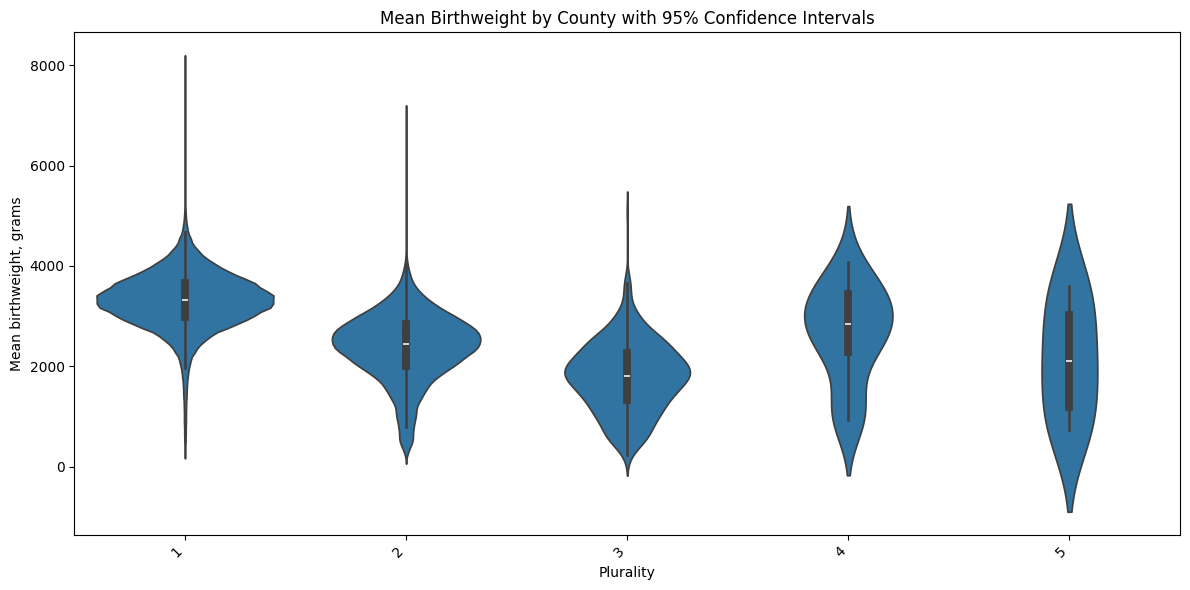

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

sns.violinplot(
    data=births,
    x="plurality",
    y="birthweight"
)

plt.xticks(rotation=45, ha="right")
plt.xlabel("Plurality")
plt.ylabel("Mean birthweight, grams")
plt.title("Mean Birthweight by Plurality with 95% Confidence Intervals")
plt.tight_layout()
plt.show()

# EXAMPLE TWO: study data 

This example uses data we collected and I will be using for a poster presentation next month

In [ ]:
# Read in T2-FLAIR self-report data from study drive 

t2flair = pd.read_csv("/Volumes/study/maia/intermediate_data/self_report/prelim_t2flair_selfreport_March2026.csv")

print(t2flair.head(10))

   subject_id acq_date_sm  acq_1_sm  acq_2_sm  acq_3_sm  acq_4_sm  acq_5_sm  \
0        3001  2024-06-14       6.0       6.0       6.0       7.0       6.0   
1        3002  2024-09-26       6.0       6.0       6.0       6.0       6.0   
2        3003  2024-10-31       6.0       9.0       9.0       9.0       6.0   
3        3004         NaN       NaN       NaN       NaN       NaN       NaN   
4        3005         NaN       NaN       NaN       NaN       NaN       NaN   
5        3006  2024-11-26       8.0       7.0       6.0       8.0       6.0   
6        3007         NaN       NaN       NaN       NaN       NaN       NaN   
7        3008         NaN       NaN       NaN       NaN       NaN       NaN   
8        3009         NaN       NaN       NaN       NaN       NaN       NaN   
9        3010  2025-01-24       7.0       7.0       8.0       8.0       8.0   

   acq_6_sm  acq_fev1_sm  acq_fev1pred_sm  ... contact_sexual_score  \
0      13.0         1.56             3.17  ...             

In [ ]:
# Read in brain lesion data from study drive

prelim_lesions=pd.read_csv("/Volumes/study/maia/intermediate_data/t2_flair/lst_lpa_march26.csv")
print(prelim_lesions.head(10))

   subject_id  num_lesions  vol_lesions_ml
0        3001          NaN             NaN
1        3002          0.0           0.000
2        3003          9.0           0.723
3        3004          NaN             NaN
4        3005          NaN             NaN
5        3006          0.0           0.000
6        3007          NaN             NaN
7        3008          NaN             NaN
8        3009          NaN             NaN
9        3010          1.0           0.202


Get info and subset relevant columns

In [18]:
t2flair.info()

list(t2flair.columns)

t2flair_subset=t2flair[["subject_id", "acq_totalscore_sm",
                        "promis_sf_v10_depression_8a_tscore",
                        "promis_sf_v10_anxiety_8a_tscore",
                        "promis_bank_v10_sleep_disturbance_tscore",
                        "dem_age_smc", "dem_sex_at_birth",
                        "asth_grp","ace_sum_binary", "pss_sum", "shaps_sum"]]



<class 'pandas.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Columns: 326 entries, subject_id to ace_sum_binary
dtypes: float64(188), int64(69), str(69)
memory usage: 234.4 KB


Merge data

In [22]:
# Merge data 
merged_data = pd.merge(t2flair_subset, prelim_lesions, on="subject_id", how="inner")
print(merged_data)

    subject_id  acq_totalscore_sm  promis_sf_v10_depression_8a_tscore  \
0         3001                1.0                                49.2   
1         3002                0.3                                64.0   
2         3003                2.1                                47.8   
3         3004                NaN                                 NaN   
4         3005                NaN                                 NaN   
..         ...                ...                                 ...   
87        4048                NaN                                45.5   
88        4049                NaN                                49.4   
89        4050                NaN                                48.8   
90        4051                NaN                                53.6   
91        4052                NaN                                 NaN   

    promis_sf_v10_anxiety_8a_tscore  promis_bank_v10_sleep_disturbance_tscore  \
0                              52.8       

In [33]:
print(vars(merged_data))

# make asthma group a category for plotting
merged_data["asth_grp"] = merged_data["asth_grp"].astype("category")

{'_mgr': BlockManager
Items: Index(['subject_id', 'acq_totalscore_sm', 'promis_sf_v10_depression_8a_tscore',
       'promis_sf_v10_anxiety_8a_tscore',
       'promis_bank_v10_sleep_disturbance_tscore', 'dem_age_smc',
       'dem_sex_at_birth', 'asth_grp', 'ace_sum_binary', 'pss_sum',
       'shaps_sum', 'num_lesions', 'vol_lesions_ml'],
      dtype='str')
Axis 1: RangeIndex(start=0, stop=92, step=1)
NumpyBlock: slice(0, 1, 1), 1 x 92, dtype: int64
NumpyBlock: slice(1, 2, 1), 1 x 92, dtype: float64
NumpyBlock: slice(2, 3, 1), 1 x 92, dtype: float64
NumpyBlock: slice(3, 4, 1), 1 x 92, dtype: float64
NumpyBlock: slice(4, 5, 1), 1 x 92, dtype: float64
NumpyBlock: slice(5, 6, 1), 1 x 92, dtype: int64
ExtensionBlock: slice(6, 7, 1), 1 x 92, dtype: str
ExtensionBlock: slice(7, 8, 1), 1 x 92, dtype: category
NumpyBlock: slice(8, 9, 1), 1 x 92, dtype: int64
NumpyBlock: slice(9, 10, 1), 1 x 92, dtype: float64
NumpyBlock: slice(10, 11, 1), 1 x 92, dtype: float64
NumpyBlock: slice(11, 12, 1), 1 x 

## Descriptive Stats/Table 

In [ ]:
# Describe 

descriptives=merged_data.describe()

print(descriptives)


        subject_id  acq_totalscore_sm  promis_sf_v10_depression_8a_tscore  \
count    92.000000          26.000000                           63.000000   
mean   3589.108696           1.001923                           48.344444   
std     501.622170           0.735299                            6.642453   
min    3001.000000           0.000000                           38.200000   
25%    3023.750000           0.332500                           44.500000   
50%    4006.500000           1.000000                           47.800000   
75%    4029.250000           1.395000                           52.850000   
max    4052.000000           3.000000                           65.000000   

       promis_sf_v10_anxiety_8a_tscore  \
count                        63.000000   
mean                         51.555556   
std                           6.571487   
min                          37.100000   
25%                          48.250000   
50%                          52.000000   
75%         

## Visuals

### Lesions by Group

Visualize distributions of lesion number by group (severe asthma vs healthy controls)

/Users/higgins/uvenv/DAIR3/lib/python3.12/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_ydensity : Removed 34 rows containing non-finite values.
/Users/higgins/uvenv/DAIR3/lib/python3.12/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_boxplot : Removed 34 rows containing non-finite values.


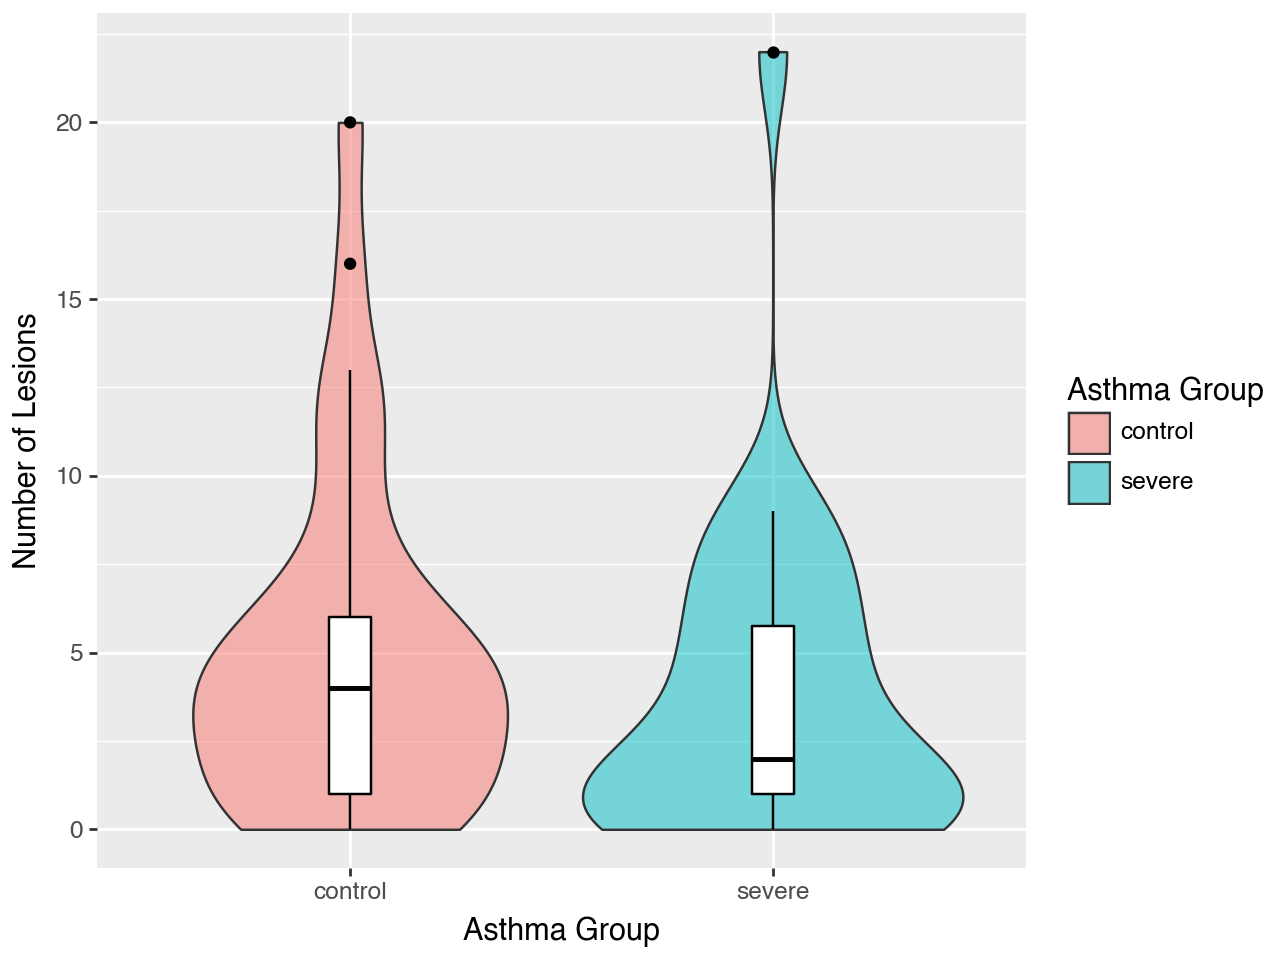

In [45]:
from plotnine import *

plot = (
    ggplot(merged_data, aes(x='asth_grp', y='num_lesions', fill='asth_grp'))
    + geom_violin(alpha=0.5)
    + geom_boxplot(width=0.1, color="black", fill="white")
    + labs(x="Asthma Group", y="Number of Lesions", fill="Asthma Group")
)

plot

## Depression-Lesions by Group

Visualize potential relationship between depressive symptom scores and number of lesions, by group (severe asthma vs healthy control)

/Users/higgins/uvenv/DAIR3/lib/python3.12/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_point : Removed 35 rows containing missing values.


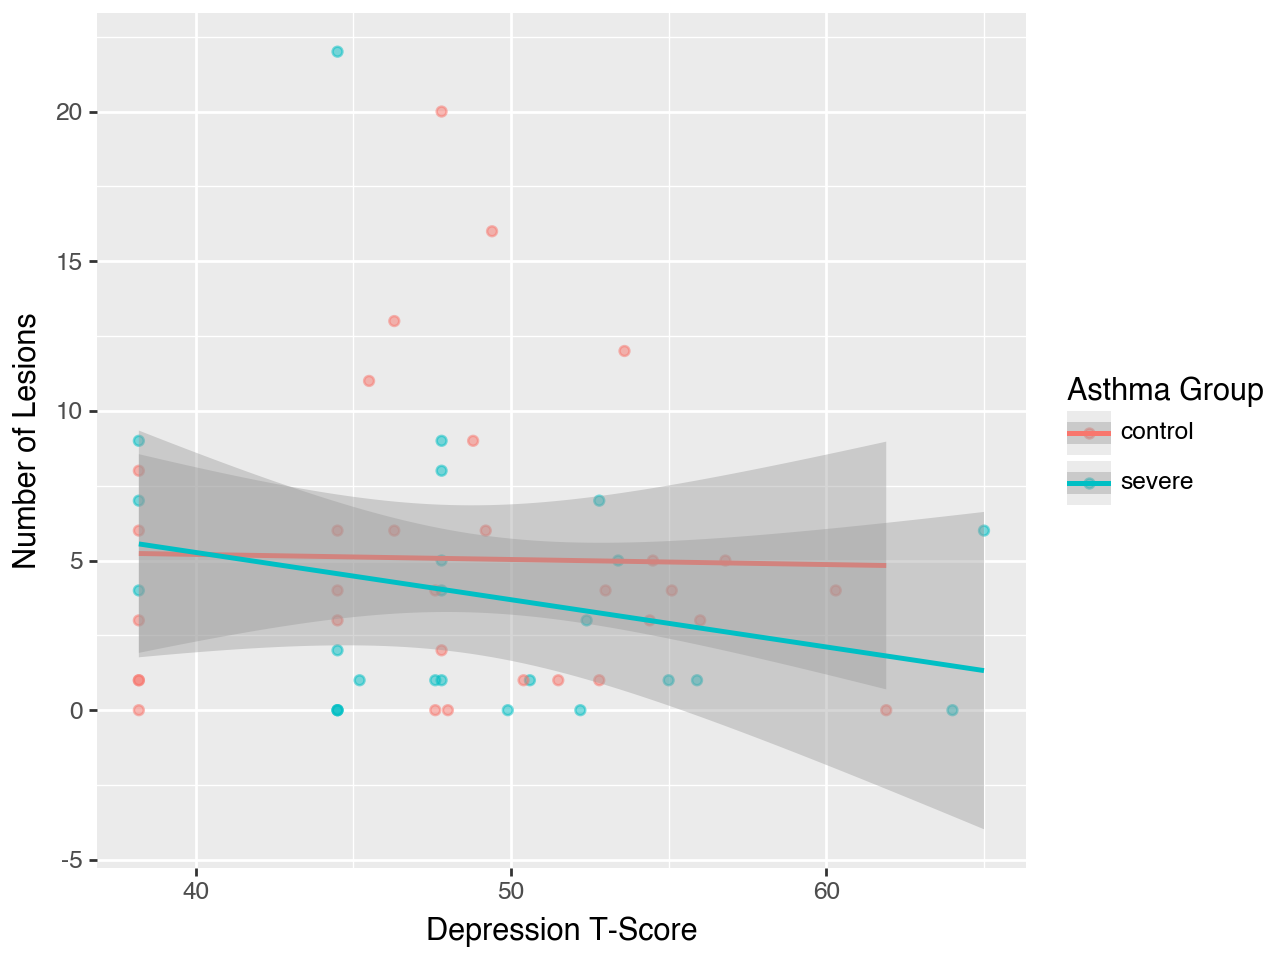

In [44]:
plot2 = (
    ggplot(merged_data, aes(x='promis_sf_v10_depression_8a_tscore', y='num_lesions', color='asth_grp'))
    + geom_point(alpha=0.5) + geom_smooth(method='lm', se=True)
    + labs(x="Depression T-Score", y="Number of Lesions", color="Asthma Group")
)

plot2